# Clustering Higashi Embeddings
Both single cell datasets we've been using were normalized and imputed using Higashi, since single cell Hi-C data is quite sparse. Higashi also generates embeddings to cluster the cells by, the clustering of which differs from the clustering observed by both UOT and HiCRep. Thus, we'll investigate these embeddings to see why this is.

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and Files ###
root = '../../'
embed_file = f'{root}Data/ramani_higashi/output/embed/exp_zinb3_0_origin.npy'
cell_types_file = f'{root}Data/ramani_cool_files/cell_line_mapping.csv'

In [3]:
### Imports ###
import sys
import numpy as np
import pandas as pd
from umap import UMAP
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
### Importing Cell Embeddings ###
cell_embeddings = np.load(embed_file)
cell_embeddings

array([[-25.14302  ,   3.353985 ,  20.30205  , ...,   9.429085 ,
          7.4415264,   3.8543975],
       [-28.6831   ,  12.562384 ,  11.843275 , ...,  14.70562  ,
         13.848177 ,   1.7907372],
       [-24.360304 ,   1.6672851,  26.773382 , ...,  17.589302 ,
          5.502603 ,   6.037048 ],
       ...,
       [-25.950645 ,   2.6547518,  13.348338 , ...,   6.3696456,
         21.339441 ,  12.013753 ],
       [-53.33703  ,  19.234625 ,  14.21955  , ...,   5.2584357,
         19.128382 ,  19.626822 ],
       [-29.879929 ,  14.2408   ,   2.5215824, ...,  13.705496 ,
         10.767992 ,  13.435268 ]], shape=(620, 64), dtype=float32)

## Adding Cell Type Info

In [7]:
cell_types = pd.read_csv(cell_types_file)

## PCA

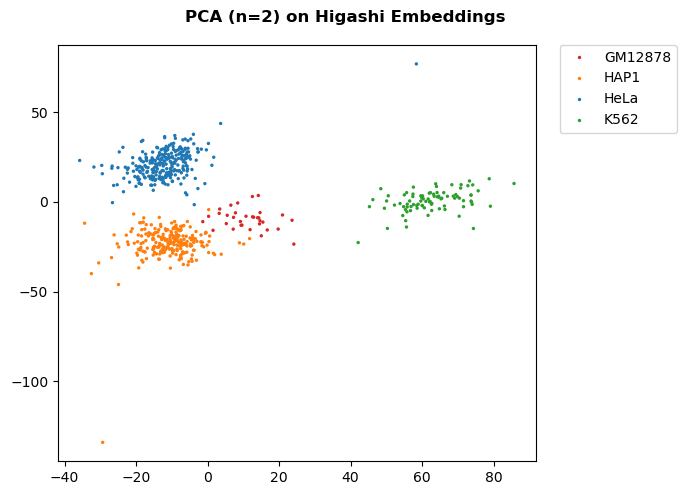

In [7]:
fig = plt.figure(figsize=(7, 5))
ax = plt.subplot(1, 1, 1)
vec = PCA(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_types["cell_line"], ax=ax, s=6, linewidth=0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
plt.suptitle("PCA (n=2) on Higashi Embeddings", fontweight='bold')
plt.tight_layout()

## UMAP

<class 'matplotlib.axes._axes.Axes'>


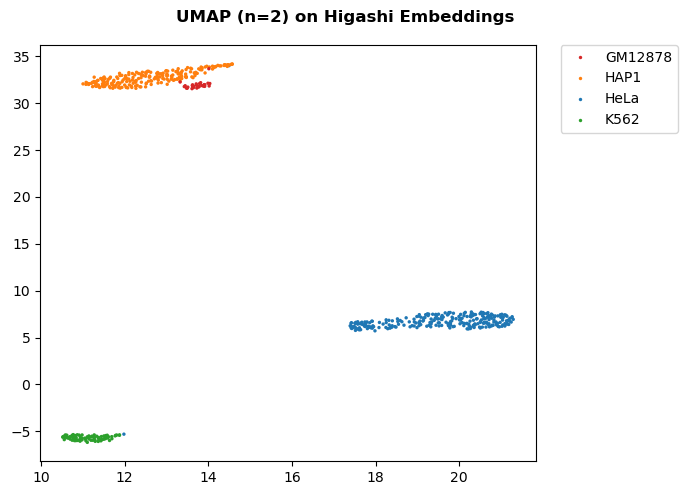

In [ ]:
fig = plt.figure(figsize=(7, 5))
ax = plt.subplot(1, 1, 1)
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_types["cell_line"], ax=ax, s=6, linewidth=0)
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=1)
plt.suptitle("UMAP (n=2) on Higashi Embeddings", fontweight='bold')
plt.tight_layout()